In [1]:
#Path has been added to include the permutation functions
import sys
import os
sys.path.append(os.path.join(os.getcwd() , ".." , "Python_scripts"))

In [2]:
#libraries
import scanpy as sc
import pandas as pd
import numpy as np
import copy
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt
import random
from permutation import freq_to_link_table , calculate_statistic , run_permutation_parallel
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist
import os


In [3]:
#Set seed
seed_number = 42

random.seed(seed_number)     # python random generator
np.random.seed(seed_number)  # numpy random generator

In [4]:
# ─── EXPERIMENT PARAMETERS — edit these before running ───────────────────────
tissue           = "NT"
injection_stage  = "HH16"
collection_stage = "HH31"

experiment_name = f"{tissue}_inj{injection_stage}_coll{collection_stage}"
print(f"Experiment: {experiment_name}")
# ─────────────────────────────────────────────────────────────────────────────

Experiment: NT_injHH16_collHH31


In [5]:
#Read in meta data
data_path = "/nemo/lab/briscoej/home/users/boeziog/LARRY/"
meta_files = os.path.join(data_path, "metadata")

chicken_meta = pd.read_csv(
    os.path.join(meta_files, f"larry_chicken_{experiment_name}.csv")
)

print(chicken_meta.head())
print(chicken_meta.columns)

                 index   sample_id  n_genes  n_genes_by_counts  total_counts  \
0  AAACCAAAGAACGGCA-25  BOE5073A25     4152               4152       13806.0   
1  AAACCAAAGCTGGAAG-25  BOE5073A25     4726               4726       17522.0   
2  AAACCATTCACCTGAA-25  BOE5073A25     5414               5414       22630.0   
3  AAACCATTCATGTGAT-25  BOE5073A25     6474               6474       34290.0   
4  AAACCATTCCGTTAAG-25  BOE5073A25     2809               2809        8364.0   

   total_counts_mt  pct_counts_mt  total_counts_ribo  pct_counts_ribo  \
0             40.0       0.289729             1508.0        10.922788   
1             52.0       0.296770             1119.0         6.386257   
2             70.0       0.309324             1332.0         5.885992   
3             92.0       0.268300             2118.0         6.176728   
4             15.0       0.179340             1320.0        15.781922   

   doublet_score  predicted_doublet      sample cell_type_final  \
0       0.007

In [6]:
# List all unique cell types
print(chicken_meta["cell_type_final"].unique())

['dI4' 'dI5' 'unclear' 'dI6' 'dpL' 'FP' 'dp6' 'V2a' 'p3' 'V1' 'RP' 'V0'
 'pMN' 'p2' 'dp1' 'V2b' 'MN' 'immature_V0_dI6' 'OPCs' 'dI1' 'V3' 'p0'
 'dI2' 'dp2' 'p1' 'dI3']


In [7]:
#Cell types of interest
#Chicken
chicken_cell_types = ["RP", "dp1", "dp2", "dpL", "dI1", "dI2", "dI3", "dI4", "dI5", 
                      "dp6", "dI6", "p0", "V0", "p1", "V1", "p2", "V2a", "V2b", 
                      "pMN", "MN", "p3", "V3", "FP", "OPCs"]

chicken_neurons = ["RP","dI1", "dI2", "dI3", "dI4", "dI5", "dI6", "V0", "V1", "V2a", "V2b", "MN", "V3", "FP"]

In [8]:
# Filter metadata for interest sets
chicken_meta_interest = chicken_meta[
    chicken_meta["cell_type_final"].isin(chicken_cell_types)
]


In [9]:
meta_interest = chicken_meta_interest.copy()
cell_types_interest = chicken_cell_types
neurons = chicken_neurons

In [10]:
#Remove cells without a clone assigned to it
meta_clone = meta_interest[~pd.isna(meta_interest["clone"])]

In [11]:
#Get amount of cells per clone/Cell type combination
clone_celltype_combo = meta_clone.groupby(["clone" , "cell_type_final"]).size().reset_index(name = "amount")
#Reshape data
clone_celltype_combo_wide = clone_celltype_combo.pivot(index = "clone" , columns="cell_type_final" , values = "amount").fillna(0).astype("int")

In [12]:
#If you want neurons only plot set neurons_only to True otherwise False
neurons_only = True

In [13]:
#Helper function to save plots recursively


figures_output = os.path.join(
    data_path, "LARRY_spinal_cord", "Jupyter_notebooks", "plots", "chicken", experiment_name
)
os.makedirs(figures_output, exist_ok=True)

def save_plot(plot_name):
    suffix = "_neurons" if neurons_only else ""
    interaction_suffix = f"_{type_of_interaction}" if type_of_interaction == "between_within" else ""
    filename = f"{plot_name}{suffix}{interaction_suffix}.pdf"
    save_path = os.path.join(figures_output, filename)
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"✅ Plot saved to {save_path}")

In [14]:
#Option of the permutation function with two possibilities:
## between: excludes interactions between cells of the same type
## between_within: includes interactions between cells of the same type
type_of_interaction = "between_within"

## Jaccard similarity

In [44]:
#Dictionay with celltypes as keys and clone names as values
celltype_clones = {celltype : set(clone_celltype_combo_wide[clone_celltype_combo_wide[celltype] > 0].index) for celltype in clone_celltype_combo_wide.columns}

In [45]:
# Initialize an empty DataFrame
jaccard_matrix = pd.DataFrame(index=cell_types_interest, columns=cell_types_interest, dtype=float)
# Initialize an empty DataFrame
clones_shared = pd.DataFrame(index=cell_types_interest, columns=cell_types_interest, dtype=float)
# Fill in the Jaccard similarity
for k1 in cell_types_interest:
    for k2 in cell_types_interest:
        
        
        
        if k1 == k2:
            jaccard_matrix.loc[k1, k2] = 0
            clones_shared.loc[k1, k2] = clone_celltype_combo_wide[(clone_celltype_combo_wide[k1] > 1)].shape[0]
        else:
            clones_shared.loc[k1, k2] = clone_celltype_combo_wide[(clone_celltype_combo_wide[k1] > 0) & (clone_celltype_combo_wide[k2] > 0)].shape[0]
            intersection = len(celltype_clones[k1] & celltype_clones[k2])
            union = len(celltype_clones[k1] | celltype_clones[k2])
            jaccard = intersection / union if union > 0 else 0
            jaccard_matrix.loc[k1, k2] = np.log(jaccard * 100 + 1e-20)


In [46]:
clones_shared

,RP,dp1,dp2,dpL,dI1,dI2,dI3,dI4,dI5,dp6,...,V1,p2,V2a,V2b,pMN,MN,p3,V3,FP,OPCs
RP,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dp1,0.0,2.0,2.0,0.0,7.0,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dp2,0.0,2.0,6.0,4.0,0.0,1.0,3.0,6.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dpL,0.0,0.0,4.0,50.0,0.0,1.0,2.0,81.0,83.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dI1,0.0,7.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dI2,0.0,2.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dI3,0.0,1.0,3.0,2.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dI4,0.0,0.0,6.0,81.0,2.0,0.0,1.0,73.0,93.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dI5,0.0,0.0,5.0,83.0,0.0,0.0,1.0,93.0,70.0,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dp6,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/clone_jaccard_heatmap_between_within.pdf


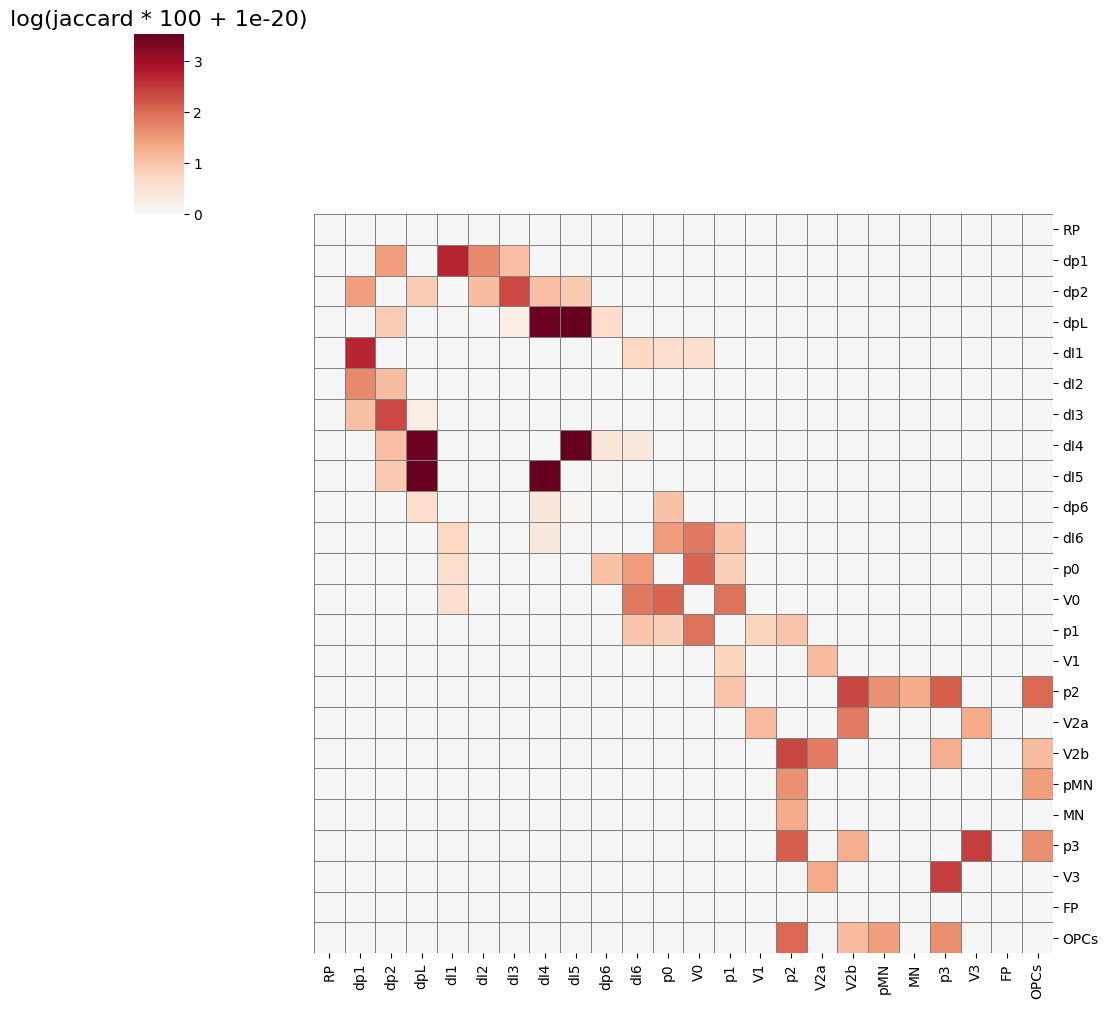

<Figure size 640x480 with 0 Axes>

In [18]:
#Fill the NA values
X = jaccard_matrix

if neurons_only:
    X = jaccard_matrix.loc[neurons,neurons]

# Overlay heatmap for significant values with higher alpha


sns.clustermap(
    X,
    cmap='RdBu_r',
    vmin=0,
    center=0,
    row_cluster=False,
    col_cluster=False,
    linewidths=0.5,
    linecolor='grey',
    figsize=(10, 10),
    method = "ward"
)

title_text = "log(jaccard * 100 + 1e-20)"

# Set the title
plt.title(title_text, fontsize=16)

save_plot("clone_jaccard_heatmap")

plt.show()
plt.clf()

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/raw_clones_heatmap_between_within.pdf


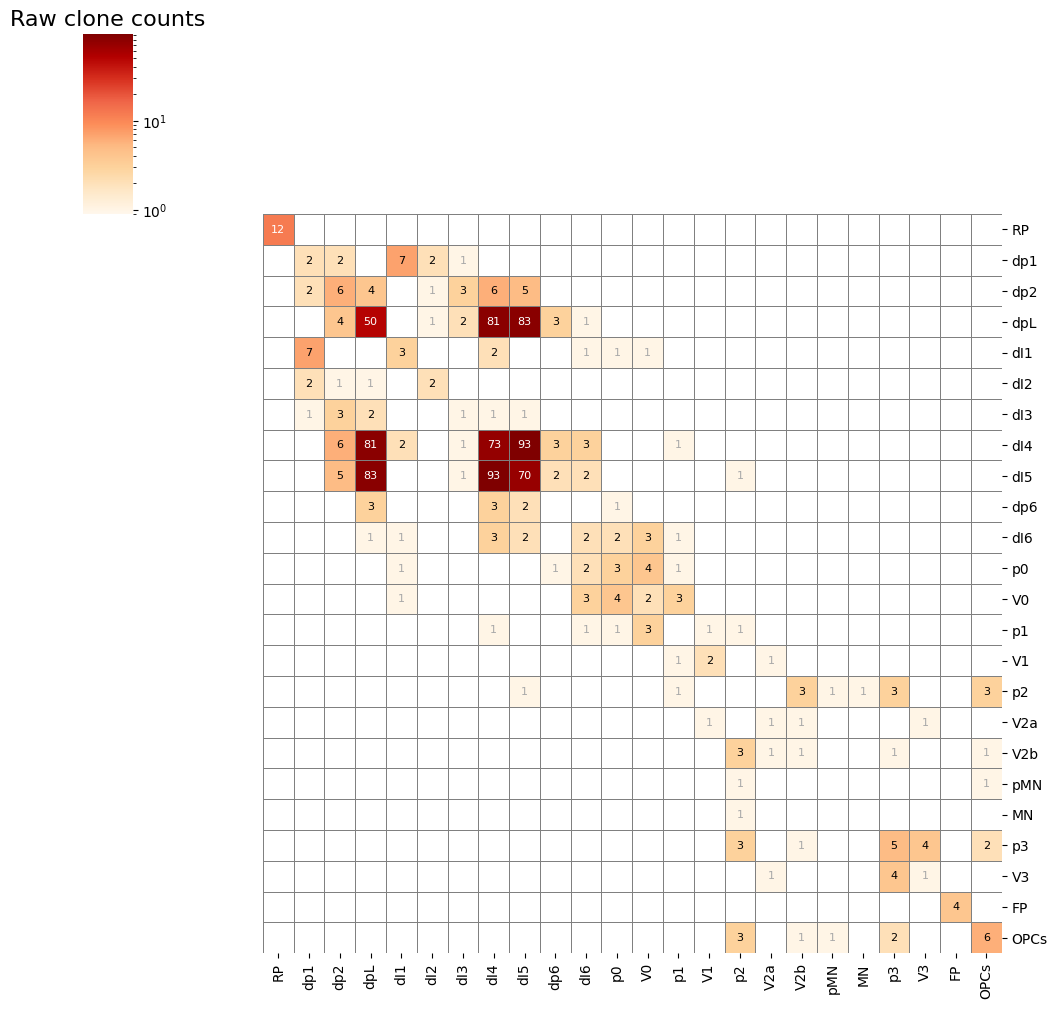

<Figure size 640x480 with 0 Axes>

In [19]:
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm

X = clones_shared

if neurons_only:
    X = clones_shared.loc[neurons,neurons]



# Plot the clustermap
g = sns.clustermap(
    X,
    cmap="OrRd",
    norm=LogNorm(vmin=0.9, vmax=clones_shared.max().max()),
    row_cluster=False,
    col_cluster=False,
    linewidths=0.5,
    linecolor='grey',
    figsize=(10, 10)
)

# Extract heatmap data and axis AFTER plotting
data = g.data2d.values
ax = g.ax_heatmap

# Add centered integer labels > 0
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if val > 0 and np.isclose(val, round(val)):
            if val == 1:
                text_color = 'darkgray'
            elif val < 10:
                text_color = 'black'
            else:
                text_color = 'white'

            ax.text(j + 0.5, i + 0.5, str(int(round(val))),
                    ha='center', va='center',
                    color=text_color,
                    fontsize=8,
                    transform=ax.transData)

# Set the title
title_text = "Raw clone counts"

# Set the title
plt.title(title_text, fontsize=16)

save_plot("raw_clones_heatmap")

plt.show()
plt.clf()


## Permutation test

In [47]:
#Number of permutations
number_permutations = 1000

In [48]:
#Option of the permutation function with two possibilities:
## between: excludes interactions between cells of the same type
## between_within: includes interactions between cells of the same type
type_of_interaction = "between_within"

In [49]:
#Option of the permutation function with four options
## combination: The weight of the connection between two different cell types within a clones is the product of their amount.
## min_link: The weight of the connection between two different cell types within a clones is the minimum of their amount.
## sum: The weight of the connection between two different cell types within a clones is the sum of their amount, both amounts should be bigger than 0.
## connection: The weight of the connection between two different cell types within a clones is 1/0, based on the presence/absence of their co-occurrence. 
cell_combo_method = "sum"

In [50]:
#Calculate the pairwise connection frequency table for our data
interaction_table = freq_to_link_table(clone_celltype_combo_wide , interaction_type = type_of_interaction ,cell_combo_method = cell_combo_method)

In [51]:
#Calculate test statistic for our data
statistic = calculate_statistic(interaction_table)

In [52]:
#Run permutation tests
permutation_results  = run_permutation_parallel(clone_celltype_combo_wide , type_of_interaction , n_jobs = 32 , cell_combo_method = cell_combo_method , number_permutations = number_permutations)

Processing elements: 100%|██████████| 1000/1000 [01:00<00:00, 16.43it/s]


In [53]:
#Calculate statistics in respect to permutation distribution
FC_data = pd.DataFrame({"observed_statistic" : statistic.values() , 'permutation_mean' : np.mean(pd.DataFrame(permutation_results),axis = 0),'permutation_std' : np.std(pd.DataFrame(permutation_results),axis = 0) , 'permutation_max' : pd.DataFrame(permutation_results).max() , 'permutation_min' : pd.DataFrame(permutation_results).min()})

#Calculate Fold Change
FC_data["FC"] = FC_data["observed_statistic"] / FC_data["permutation_mean"] 

#Min Max normalisation
FC_data["min_max_norm"] = (FC_data["observed_statistic"] - FC_data["permutation_min"]) / (FC_data["permutation_max"] - FC_data["permutation_min"])

#Z score
FC_data["zscore"] = (FC_data["observed_statistic"] - FC_data["permutation_mean"]) / (FC_data["permutation_std"])

In [54]:
#Statistic of choice
stat_choice = "zscore"
zscores = {combo: 0 if np.isnan(FC) else FC for combo , FC in zip(FC_data.index , FC_data[stat_choice] )}

### Plot z-score matrix

In [55]:
# #Order of plotting
# plot_order = cell_types_interest

# #Create the zscore data matrix
# zscore_matrix = pd.DataFrame(index=plot_order, columns=plot_order)
# for combination , zscore in zscores.items():
#     el1 = combination.split("|")[0]
#     el2 = combination.split("|")[1]

#     zscore_matrix.at[el1 , el2] = zscore
#     zscore_matrix.at[el2 , el1] = zscore

# #Inspect zscore_matrix
# zscore_matrix

# #Calculate the correlation in co-occurrence pattern between cell types
# lineag_coupling_corr = copy.deepcopy(zscore_matrix)

# cell_types = zscore_matrix.columns

# #Calculate pearson correlation for every cell type combination
# for cell_type_len in range(len(cell_types)):
#     for cell_type_2 in cell_types[cell_type_len:]:
#         cell_type_1 = cell_types[cell_type_len]

#         one = pd.DataFrame(zscore_matrix[cell_type_1].drop([cell_type_1,cell_type_2]))[cell_type_1]
#         two = pd.DataFrame(zscore_matrix[cell_type_2].drop([cell_type_1,cell_type_2]))[cell_type_2]

#         lineag_coupling_corr.at[cell_type_1 , cell_type_2] = st.pearsonr(one , two).statistic
#         lineag_coupling_corr.at[cell_type_2 , cell_type_1] = lineag_coupling_corr.at[cell_type_1 , cell_type_2]

# #Select only neuron if selected
# if neurons_only:
#     zscore_matrix = zscore_matrix.loc[neurons,neurons]
#     clones_shared = clones_shared.loc[neurons,neurons]
#     plot_order = neurons

####

# Order of plotting
plot_order = cell_types_interest

# Create the z-score data matrix
zscore_matrix = pd.DataFrame(index=plot_order, columns=plot_order)
for combination, zscore in zscores.items():
    el1, el2 = combination.split("|")
    zscore_matrix.at[el1, el2] = zscore
    zscore_matrix.at[el2, el1] = zscore

# Initialize correlation matrix
lineag_coupling_corr = pd.DataFrame(index=zscore_matrix.columns, columns=zscore_matrix.columns)
cell_types = zscore_matrix.columns

# Calculate Pearson correlation for every cell type combination (including diagonals)
for cell_type_len in range(len(cell_types)):
    for cell_type_2 in cell_types[cell_type_len:]:
        cell_type_1 = cell_types[cell_type_len]

        # Extract full columns, keep diagonals, coerce to float
        one = pd.to_numeric(zscore_matrix[cell_type_1], errors='coerce')
        two = pd.to_numeric(zscore_matrix[cell_type_2], errors='coerce')

        # # Drop NaNs from both
        valid_idx = one.notna() & two.notna()
        one_clean = one[valid_idx]
        two_clean = two[valid_idx]

        # Calculate Pearson r if enough data
        if len(one_clean) > 1:
            r = st.pearsonr(one_clean, two_clean).statistic
        else:
            r = np.nan

        # Fill symmetrically
        lineag_coupling_corr.at[cell_type_1, cell_type_2] = r
        lineag_coupling_corr.at[cell_type_2, cell_type_1] = r

# Select only neurons if selected
if neurons_only:
    zscore_matrix = zscore_matrix.loc[neurons, neurons]
    clones_shared = clones_shared.loc[neurons, neurons]
    plot_order = neurons




In [56]:
#Fill the NA valuesx
X = np.array(zscore_matrix.fillna(0))

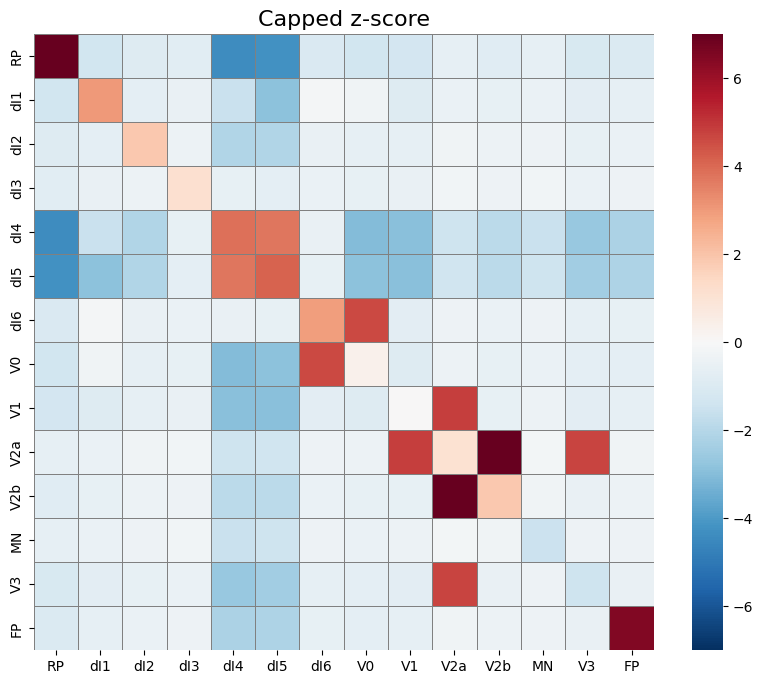

<Figure size 640x480 with 0 Axes>

In [57]:
#Fill the NA values
X = np.array(zscore_matrix.fillna(0))

plt.figure(figsize=(10, 8))

mask = np.array(clones_shared) < 1


# Base layer: low alpha (faded values for all cells)
sns.heatmap(
    X,
    cmap='RdBu_r',
    vmin=-7,
    vmax=7,
    center=0,
    linewidths=0.5,
    linecolor='grey',
    xticklabels=plot_order,
    yticklabels=plot_order,
    alpha=0.1,
    cbar=False
)


# Top layer: high alpha, mask low-confidence cells
sns.heatmap(
    X,
    #mask=mask,
    cmap='RdBu_r',
    vmin=-7,
    vmax=7,
    center=0,
    linewidths=0.5,
    linecolor='grey',
    xticklabels=plot_order,
    yticklabels=plot_order,
    alpha=1.0
)


title_text = "Capped z-score"

# Set the title
plt.title(title_text, fontsize=16)


#save_plot("clone_zscore_heatmap")

# Then show/clear
plt.show()
plt.clf()


### Plot correlation matrix

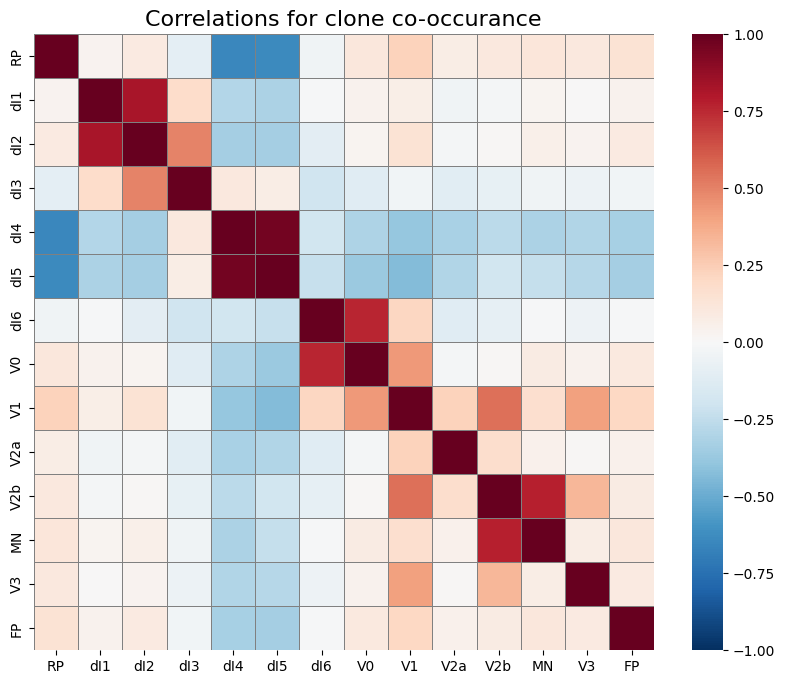

<Figure size 640x480 with 0 Axes>

In [58]:
#Select only neuron if selected
if neurons_only:
    lineag_coupling_corr = lineag_coupling_corr.loc[neurons,neurons]
    plot_order = neurons

#Fill the NA values
X = np.array(lineag_coupling_corr.fillna(0))


plt.figure(figsize=(10, 8))

mask = np.array(clones_shared) < 2

sns.heatmap(X, 
            #mask = mask, 
            linewidths=0.5,linecolor='grey',
            alpha=1.0, 
            xticklabels = plot_order , yticklabels = plot_order, vmin=-1, vmax=1 , 
            cmap='RdBu_r', center=0)

title_text = "Correlations for clone co-occurance"

# Set the title for the colorbar
plt.title(title_text, fontsize=16)

#save_plot("clone_correlation_heatmap")

plt.show()
plt.clf()

### Plot correlation matrix with corresponding z-score
Correlation matrix and z-score values must have the same sign. otherwise they are taken out.

In [59]:
#Compare zscore sign with correlation sign
same_sign = np.sign(lineag_coupling_corr) == np.sign(zscore_matrix.fillna(0))

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/clone_correlation_concordant_heatmap_neurons_between_within.pdf


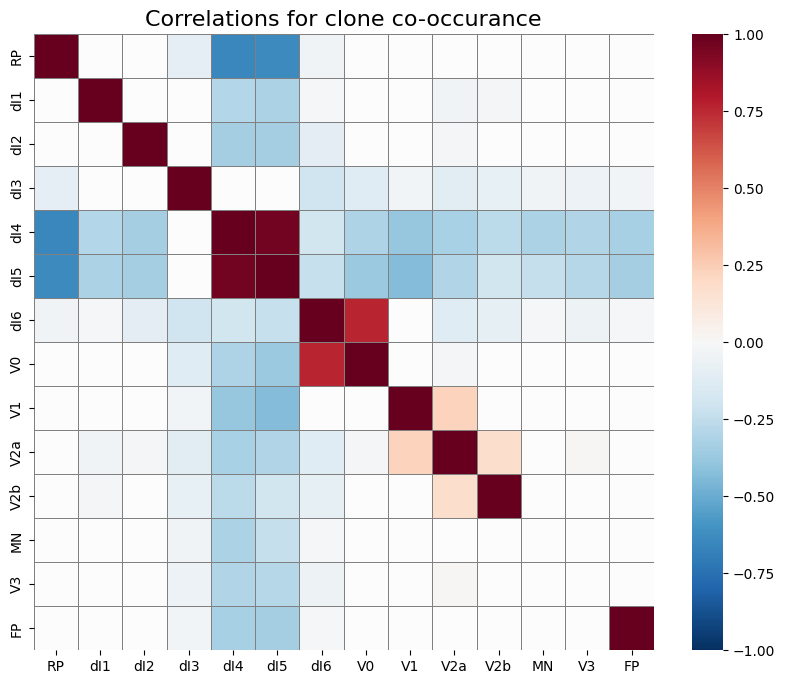

<Figure size 640x480 with 0 Axes>

In [63]:
#Only correlation with corresponding zscore sign
corresponding_sign = lineag_coupling_corr.where(same_sign)

#Select only neuron if selected
if neurons_only:
    corresponding_sign = corresponding_sign.loc[neurons,neurons]
    plot_order = neurons

#Fill the NA values
X = np.array(lineag_coupling_corr.where(same_sign), dtype = float)

# mask = np.isnan(X)
mask = np.array(clones_shared) < 1

plt.figure(figsize=(10, 8))

sns.heatmap(X, alpha=1.0, 
            #mask = mask,
            linewidths=0.5,
            linecolor='grey',
            xticklabels = plot_order , 
            yticklabels = plot_order, 
            vmin=-1, vmax=1 , 
            cmap='RdBu_r', center=0)
plt.gca().set_facecolor((0.99, 0.99, 0.99))

title_text = "Correlations for clone co-occurance"

# Set the title for the colorbar
plt.title(title_text, fontsize=16)

save_plot("clone_correlation_concordant_heatmap")

plt.show()
plt.clf()

### Hierarchical clustering of zscore

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/clone_hierarhical_zscore_heatmap_neurons_between_within.pdf


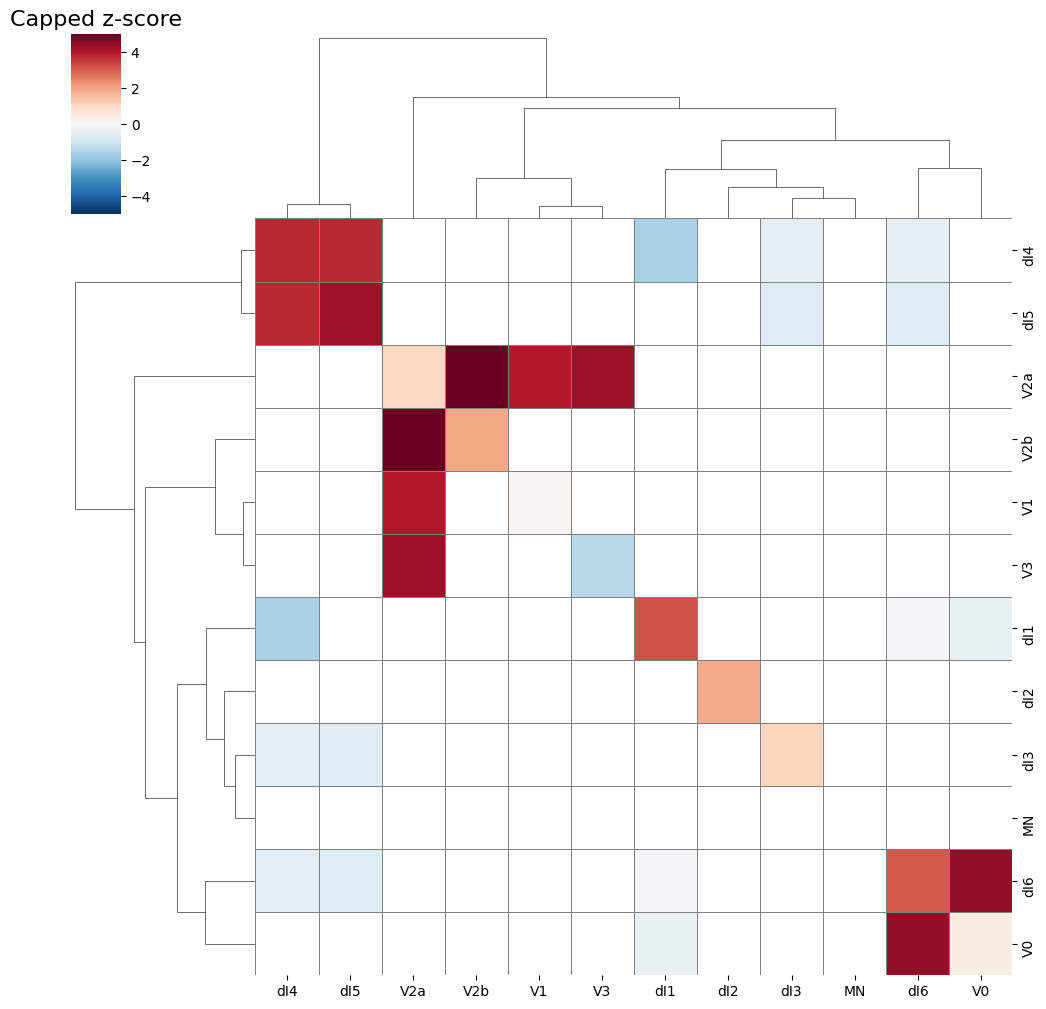

<Figure size 640x480 with 0 Axes>

In [181]:
#Fill the NA values
X = zscore_matrix.fillna(0)

if neurons_only:
    X = X.loc[neurons,neurons]



# Overlay heatmap for significant values with higher alpha
mask = np.array(clones_shared) < 1

sns.clustermap(
    X,
    mask = mask,
    cmap='RdBu_r',
    vmin=-5,
    vmax=5,
    center=0,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.5,
    linecolor='grey',
    figsize=(10, 10),
    method = "ward"
)

title_text = "Capped z-score"

# Set the title
plt.title(title_text, fontsize=16)

save_plot("clone_hierarhical_zscore_heatmap")

plt.show()
plt.clf()

### Hierarchical clustering of correlation matrix with corresponding z-score

In [188]:
# 1. Fill the NA values and restrict to neuron subset if needed
X = lineag_coupling_corr.where(same_sign)

if neurons_only:
    X = X.loc[neurons,neurons]

X_fillna = X.fillna(0)

# 2. Compute linkage
all_linkage = linkage(pdist(X_fillna.values), method='ward')

In [189]:

# 3. Define recursive resolve function
def resolve(cluster_id, labels, linkage_matrix):
    """
    Recursively resolve the members of a cluster by ID using the linkage matrix.

    Parameters:
    - cluster_id: int, cluster index (>= len(labels) means non-leaf)
    - labels: list of leaf labels (e.g., cell types)
    - linkage_matrix: the hierarchical clustering linkage matrix

    Returns:
    - list of leaf labels in this cluster
    """
    if cluster_id < len(labels):
        return [labels[cluster_id]]
    else:
        cluster_id -= len(labels)
        left = int(linkage_matrix[cluster_id][0])
        right = int(linkage_matrix[cluster_id][1])
        return resolve(left, labels, linkage_matrix) + resolve(right, labels, linkage_matrix)

# 4. Inspect clusters (e.g., bottom-up or top-down)
labels = X_fillna.columns.tolist()
n = len(labels)

print("=== Inspecting last few cluster merges ===")
for i in reversed(range(n, len(all_linkage) + n)):
    members = resolve(i, labels, all_linkage)
    print(f"Row {i - n}: {members}")

=== Inspecting last few cluster merges ===
Row 10: ['dI4', 'dI5', 'dI6', 'V0', 'V1', 'V2a', 'dI3', 'V2b', 'dI2', 'dI1', 'MN', 'V3']
Row 9: ['dI6', 'V0', 'V1', 'V2a', 'dI3', 'V2b', 'dI2', 'dI1', 'MN', 'V3']
Row 8: ['V1', 'V2a', 'dI3', 'V2b', 'dI2', 'dI1', 'MN', 'V3']
Row 7: ['dI3', 'V2b', 'dI2', 'dI1', 'MN', 'V3']
Row 6: ['V2b', 'dI2', 'dI1', 'MN', 'V3']
Row 5: ['dI2', 'dI1', 'MN', 'V3']
Row 4: ['dI1', 'MN', 'V3']
Row 3: ['V1', 'V2a']
Row 2: ['dI6', 'V0']
Row 1: ['dI4', 'dI5']
Row 0: ['MN', 'V3']


In [184]:
#If need to swap more, run each of these block and then inspect
#Blocks for all chicken
tmp = all_linkage[2].copy()
all_linkage[2] = all_linkage[3]
all_linkage[3] = tmp

In [185]:
tmp = all_linkage[7].copy()
all_linkage[7] = all_linkage[9]
all_linkage[9] = tmp

In [186]:
tmp = all_linkage[7].copy()
all_linkage[7] = all_linkage[11]
all_linkage[11] = tmp

IndexError: index 11 is out of bounds for axis 0 with size 11

In [ ]:
tmp = all_linkage[14].copy()
all_linkage[14] = all_linkage[16]
all_linkage[16] = tmp

In [ ]:
for i in range(22):  # adjust range to see more
    cluster = resolve(i + len(X_fillna), X_fillna.columns.tolist(), all_linkage)
    print(f"Row {i}: {cluster}")

ValueError: Linkage 'Z' uses non-singleton cluster before it is formed.

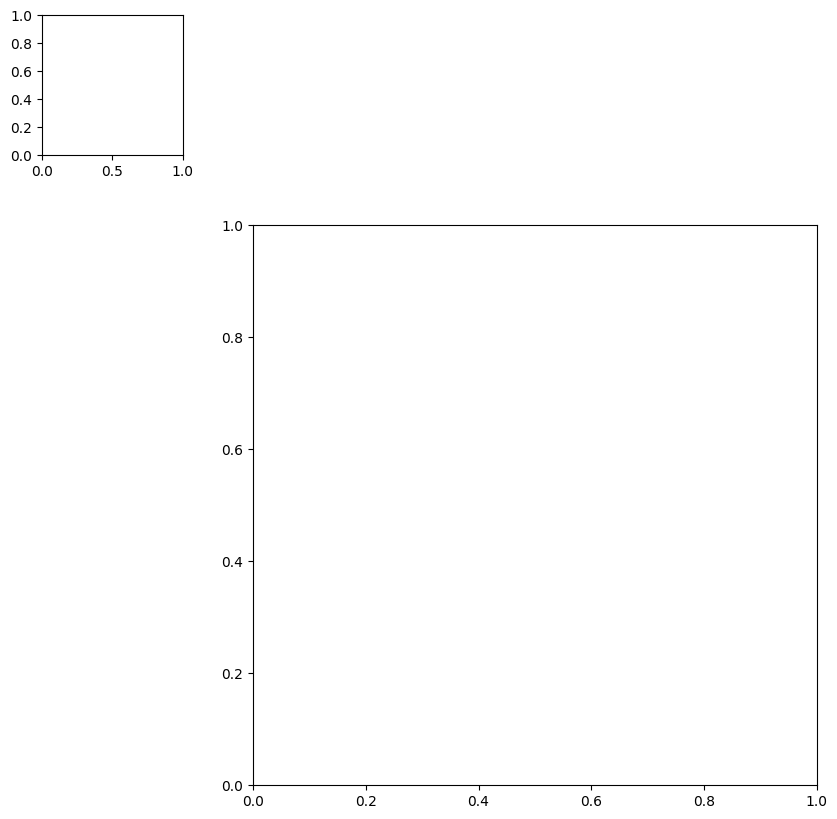

In [187]:
## Overlay heatmap for significant values with higher alpha
mask = np.array(clones_shared) < 2
sns.clustermap(
    X_fillna,
    mask = mask,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    row_linkage = all_linkage,
    col_linkage = all_linkage,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.5,
    linecolor='grey',
    figsize=(10, 10),
    method = "ward"
)

title_text = "Correlations for clone co-occurance"

# Set the title
plt.title(title_text, fontsize=16)

save_plot("clone_hierarhical_correlation_concordant_heatmap")
plt.show()
plt.clf()

## Sankey plots — lineage subdivision clone connectivity

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_Sub_1_NT_injHH16_collHH31.pdf


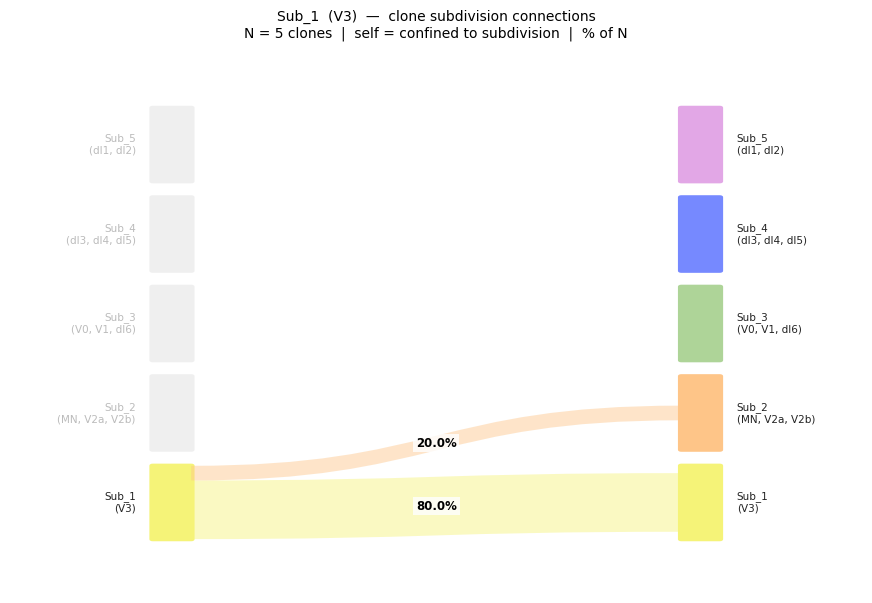

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_Sub_2_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

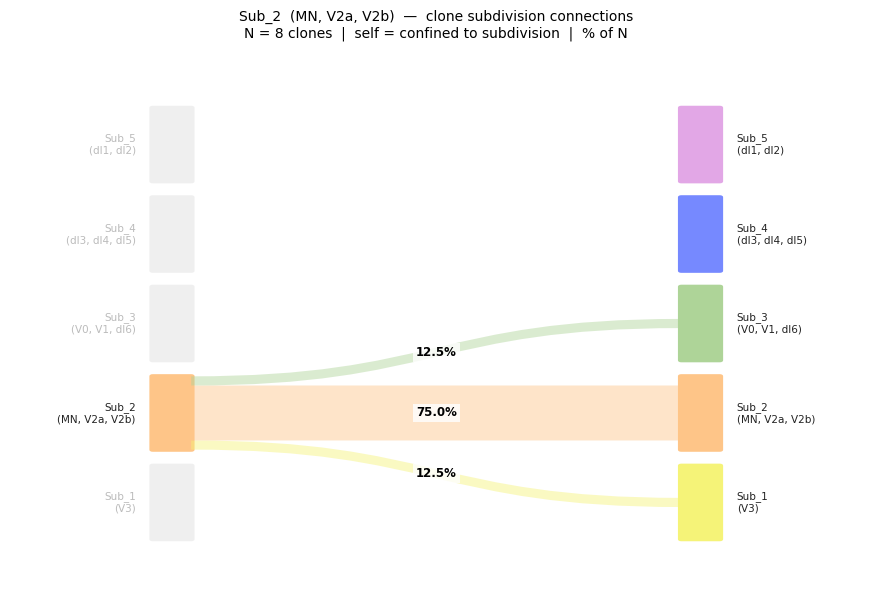

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_Sub_3_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

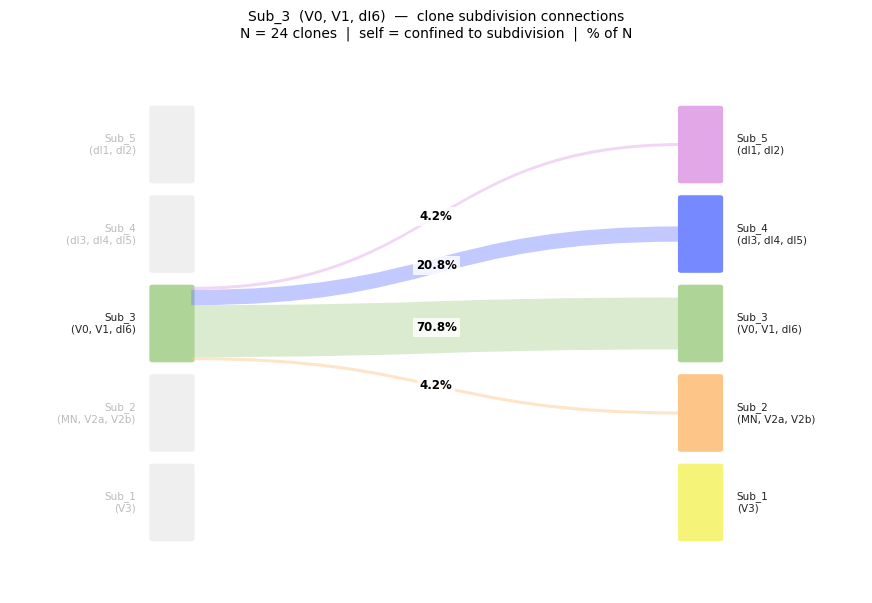

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_Sub_4_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

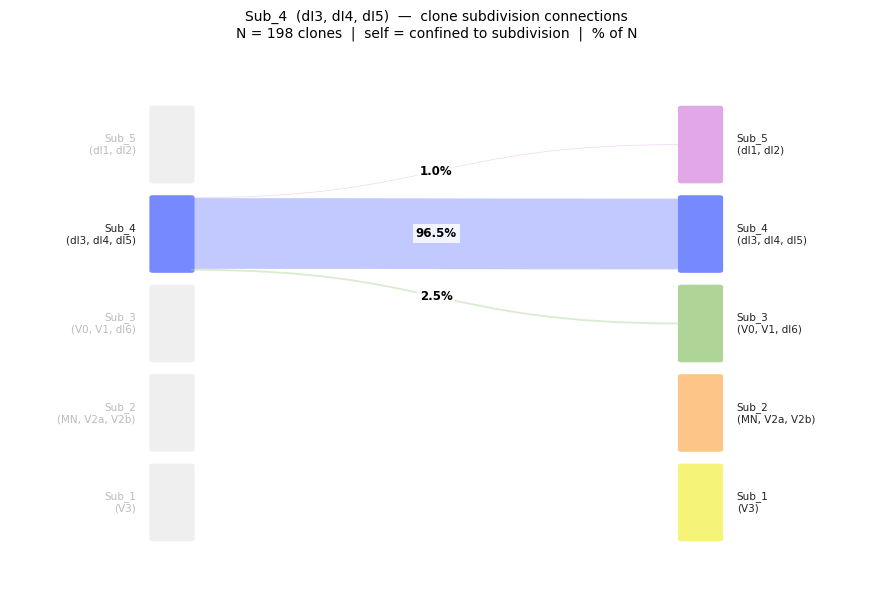

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_Sub_5_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

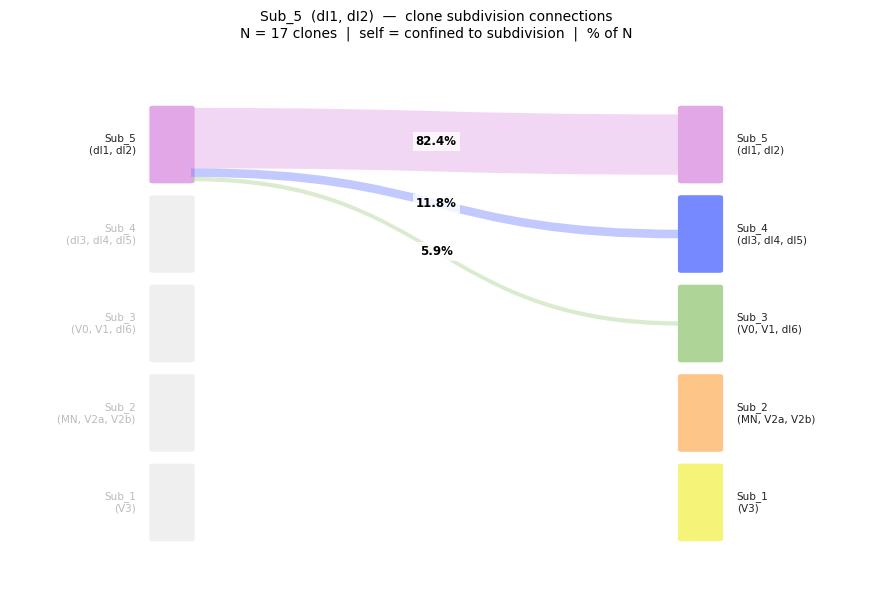

<Figure size 640x480 with 0 Axes>

In [15]:
from matplotlib.path import Path
import matplotlib.patches as mpatches

# ── Subdivision definition ────────────────────────────────────────────────────
lineage_subdivision_map = {
    "V3":  "Sub_1",
    "MN":  "Sub_2", "V2a": "Sub_2", "V2b": "Sub_2",
    "V0":  "Sub_3", "V1":  "Sub_3", "dI6": "Sub_3",
    "dI3": "Sub_4", "dI4": "Sub_4", "dI5": "Sub_4",
    "dI1": "Sub_5", "dI2": "Sub_5",
}

sub_labels = {
    "Sub_1": "Sub_1\n(V3)",
    "Sub_2": "Sub_2\n(MN, V2a, V2b)",
    "Sub_3": "Sub_3\n(V0, V1, dI6)",
    "Sub_4": "Sub_4\n(dI3, dI4, dI5)",
    "Sub_5": "Sub_5\n(dI1, dI2)",
}

sub_palette = {
    "Sub_1": "#f5f378",   # pale yellow
    "Sub_2": "#fec588",   # peach orange
    "Sub_3": "#aed498",   # sage green
    "Sub_4": "#7689ff",   # periwinkle blue
    "Sub_5": "#e2a7e6",   # lavender pink
}

sub_order = ["Sub_1", "Sub_2", "Sub_3", "Sub_4", "Sub_5"]

sub_members = {}
for ct, sub in lineage_subdivision_map.items():
    sub_members.setdefault(sub, []).append(ct)

# ── Data: multi-cell filter from full metadata, then restrict to subdivision neurons ──
_multi_cell_idx = (chicken_meta[~pd.isna(chicken_meta["clone"])]
                   .groupby("clone").size()
                   .pipe(lambda s: s[s >= 2]).index)

neuron_cols = [c for c in clone_celltype_combo_wide.columns if c in lineage_subdivision_map]
cn = clone_celltype_combo_wide.loc[clone_celltype_combo_wide.index.isin(_multi_cell_idx), neuron_cols].copy()
cn = cn[cn.sum(axis=1) >= 1]

for sub in sub_order:
    members_in_data = [c for c in sub_members[sub] if c in cn.columns]
    cn[f"n_{sub}"] = cn[members_in_data].sum(axis=1)

# ── Bezier band ───────────────────────────────────────────────────────────────
def _bezier_band(ax, x0, y0b, y0t, x1, y1b, y1t, color, alpha=0.45):
    cx = (x0 + x1) / 2
    verts = [
        (x0, y0b), (cx, y0b), (cx, y1b), (x1, y1b),
        (x1, y1t), (cx, y1t), (cx, y0t), (x0, y0t),
        (x0, y0b),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(mpatches.PathPatch(
        Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha
    ))

# ── Sankey per focal subdivision ──────────────────────────────────────────────
def draw_subdivision_sankey(focal_sub):
    focal_clones = cn[cn[f"n_{focal_sub}"] >= 1]
    N_total = len(focal_clones)
    if N_total == 0:
        print(f"No clones for {focal_sub}, skipping.")
        return

    # Line drawing rules:
    #   self  (Sub_X → Sub_X): clone confined to Sub_X (0 cells in any other sub)
    #   cross (Sub_X → Sub_Y): clone has ≥1 cell in Sub_X AND ≥1 cell in Sub_Y
    counts = {}
    for t in sub_order:
        if t == focal_sub:
            other_cols = [f"n_{s}" for s in sub_order if s != focal_sub]
            counts[t] = int((focal_clones[other_cols].sum(axis=1) == 0).sum())
        else:
            counts[t] = int((focal_clones[f"n_{t}"] >= 1).sum())

    pcts = {t: 100 * counts[t] / N_total for t in sub_order}

    # ── layout ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    nw = 0.45
    xl, xr = 1.9, 8.1
    y0, total_h = 1.0, 8.0
    n = len(sub_order)
    gap = 0.3
    nh = (total_h - (n - 1) * gap) / n

    ybot = [y0 + i * (nh + gap) for i in range(n)]
    ycen = [yb + nh / 2 for yb in ybot]
    idx  = {s: i for i, s in enumerate(sub_order)}

    # left nodes: focal coloured, others grey
    for i, sub in enumerate(sub_order):
        is_focal = sub == focal_sub
        fc = sub_palette[sub] if is_focal else "#CCCCCC"
        al = 1.0 if is_focal else 0.3
        ax.add_patch(mpatches.FancyBboxPatch(
            (xl - nw / 2, ybot[i]), nw, nh,
            boxstyle="round,pad=0.04", facecolor=fc, edgecolor="none", alpha=al,
        ))
        ax.text(xl - nw / 2 - 0.2, ycen[i], sub_labels[sub],
                ha="right", va="center", fontsize=7.5,
                color="#222222" if is_focal else "#BBBBBB")

    # right nodes: all coloured
    for i, sub in enumerate(sub_order):
        ax.add_patch(mpatches.FancyBboxPatch(
            (xr - nw / 2, ybot[i]), nw, nh,
            boxstyle="round,pad=0.04", facecolor=sub_palette[sub], edgecolor="none",
        ))
        ax.text(xr + nw / 2 + 0.2, ycen[i], sub_labels[sub],
                ha="left", va="center", fontsize=7.5, color="#222222")

    # ── flows ─────────────────────────────────────────────────────────────────
    fi = idx[focal_sub]
    scale = nh / N_total
    left_cursor = ybot[fi]

    for t in sub_order:
        c = counts[t]
        if c == 0:
            continue
        fh = c * scale
        ti = idx[t]

        ly_b, ly_t = left_cursor, left_cursor + fh
        ry_b = ycen[ti] - fh / 2
        ry_t = ycen[ti] + fh / 2

        _bezier_band(
            ax,
            xl + nw / 2, ly_b, ly_t,
            xr - nw / 2, ry_b, ry_t,
            color=sub_palette[t], alpha=0.45,
        )

        mid_y = ((ly_b + ly_t) / 2 + (ry_b + ry_t) / 2) / 2
        ax.text(5.0, mid_y, f"{pcts[t]:.1f}%",
                ha="center", va="center", fontsize=8.5, fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2))

        left_cursor += fh

    ax.set_title(
        f"{focal_sub}  ({', '.join(sub_members[focal_sub])})  —  clone subdivision connections\n"
        f"N = {N_total} clones  |  self = confined to subdivision  |  % of N",
        fontsize=10, pad=12,
    )

    fname = os.path.join(figures_output, f"sankey_{focal_sub}_{experiment_name}.pdf")
    plt.savefig(fname, format="pdf", bbox_inches="tight")
    print(f"✅ Saved: {fname}")
    plt.show()
    plt.clf()


for fs in sub_order:
    draw_subdivision_sankey(fs)

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_FP_NT_injHH16_collHH31.pdf


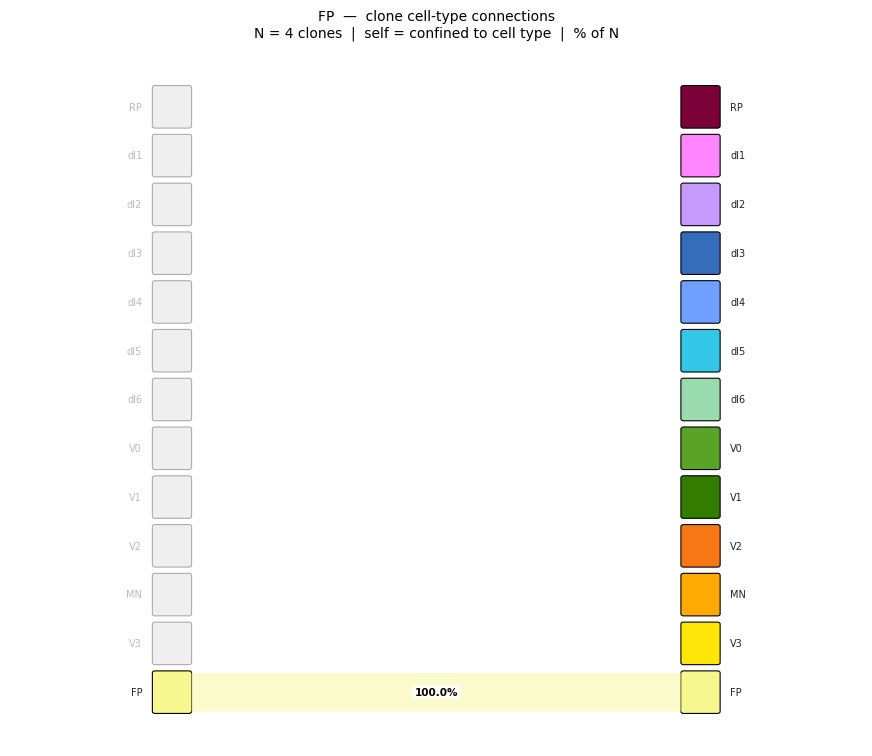

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_V3_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

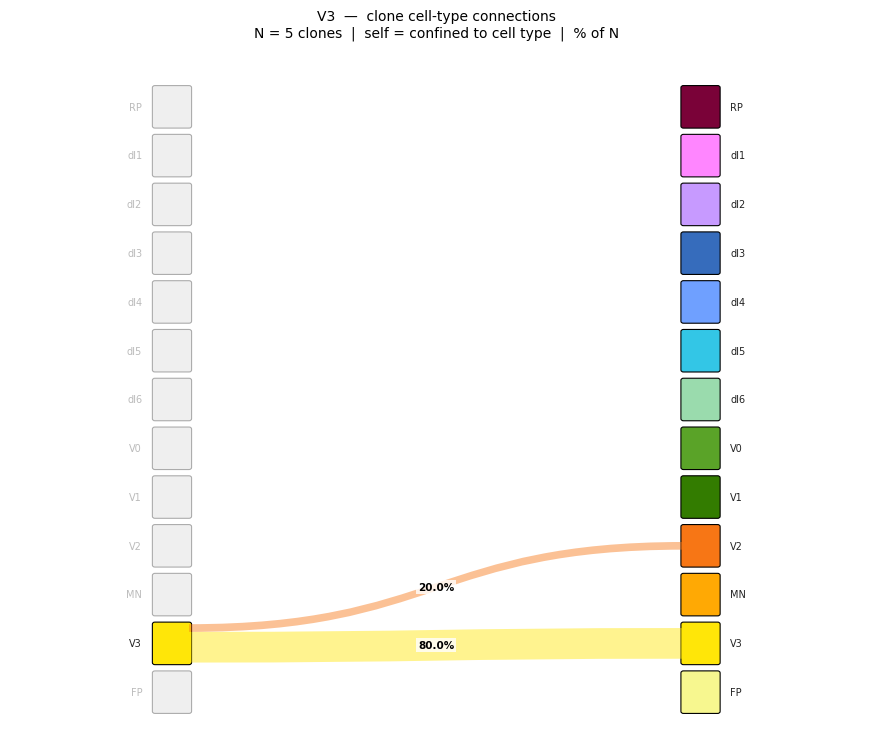

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_MN_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

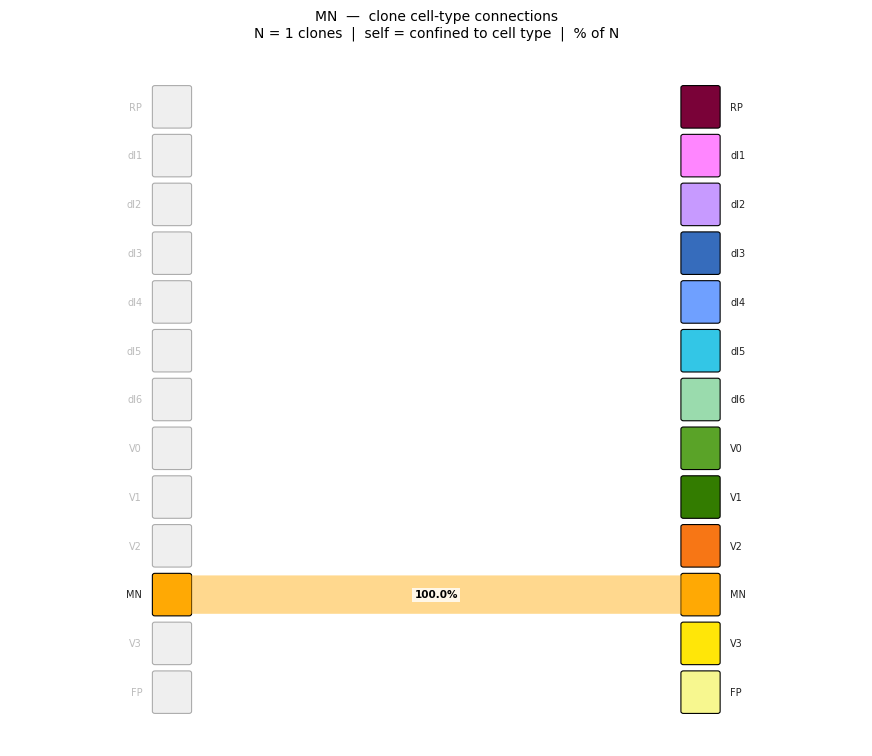

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_V2_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

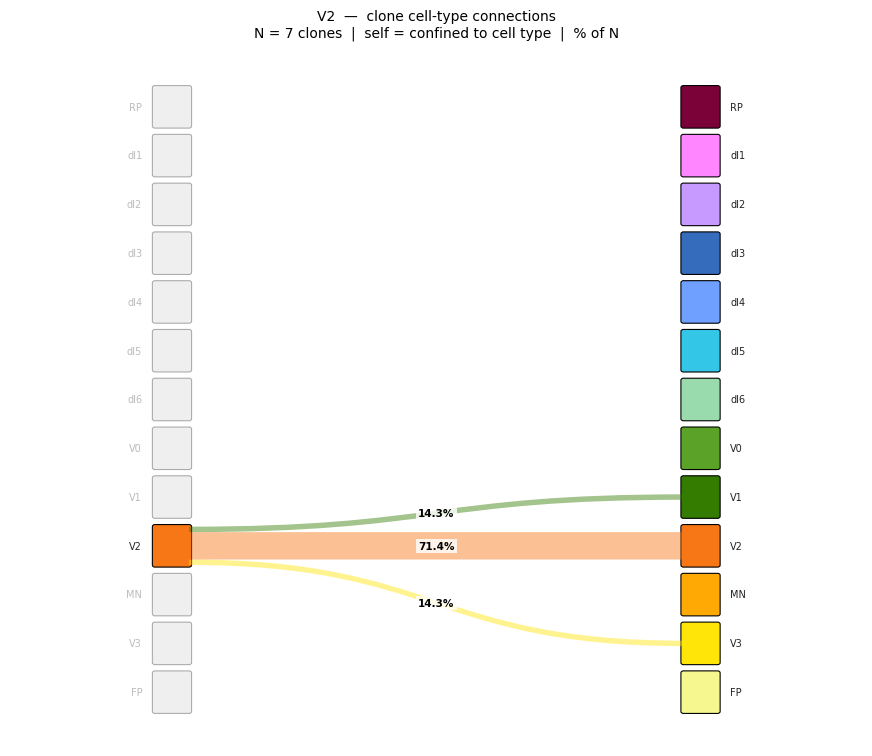

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_V1_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

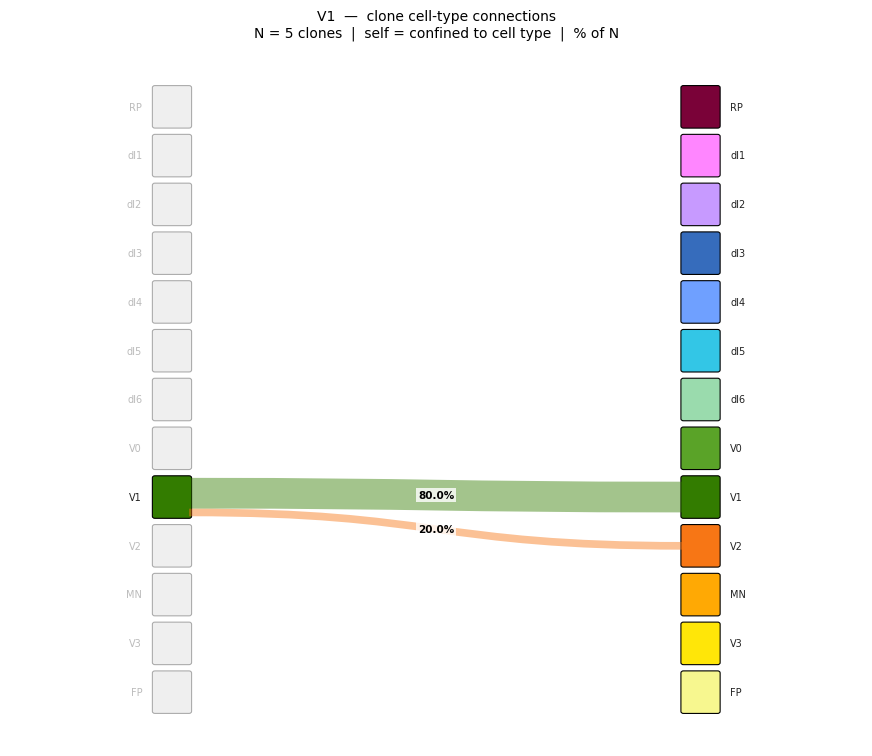

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_V0_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

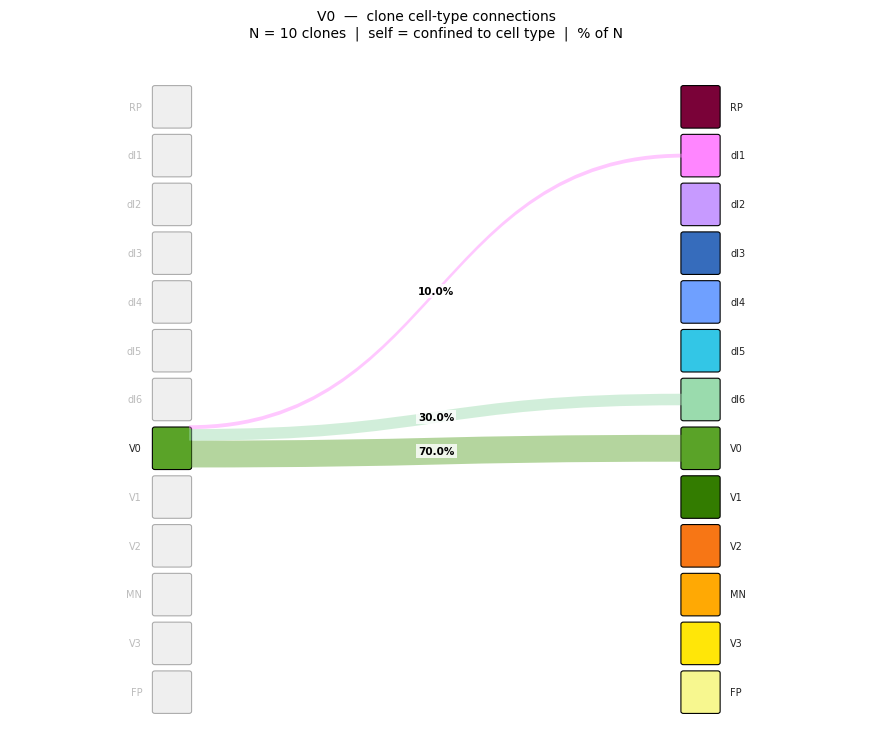

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_dI6_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

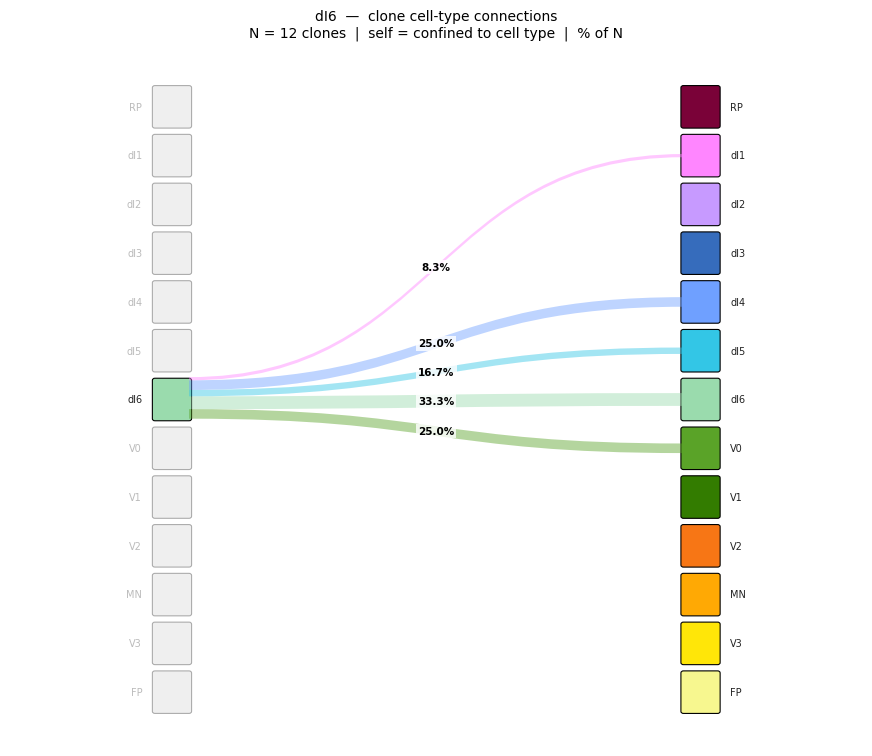

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_dI5_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

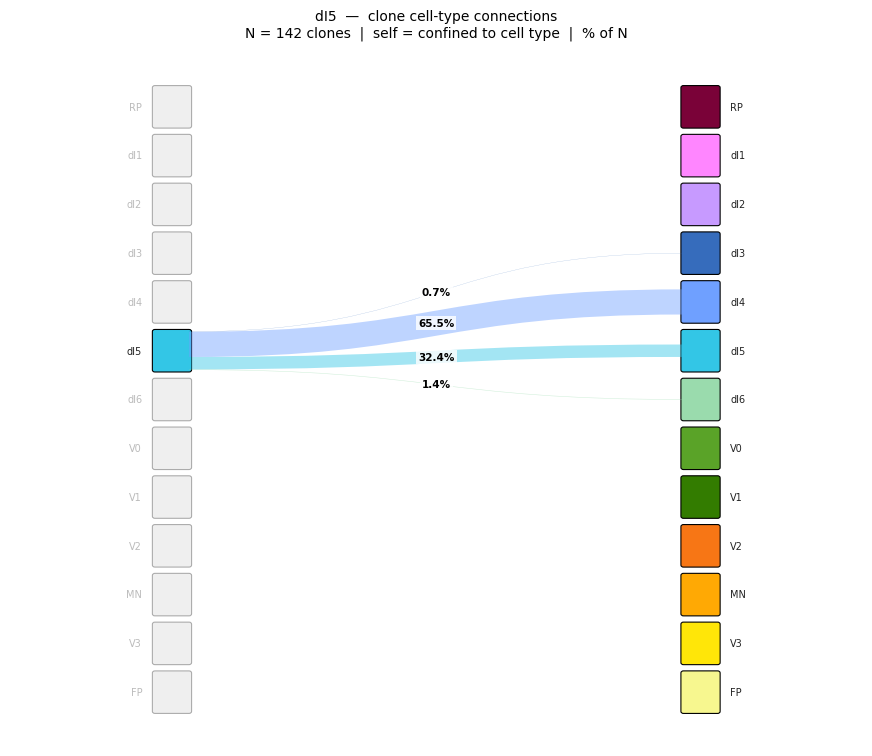

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_dI4_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

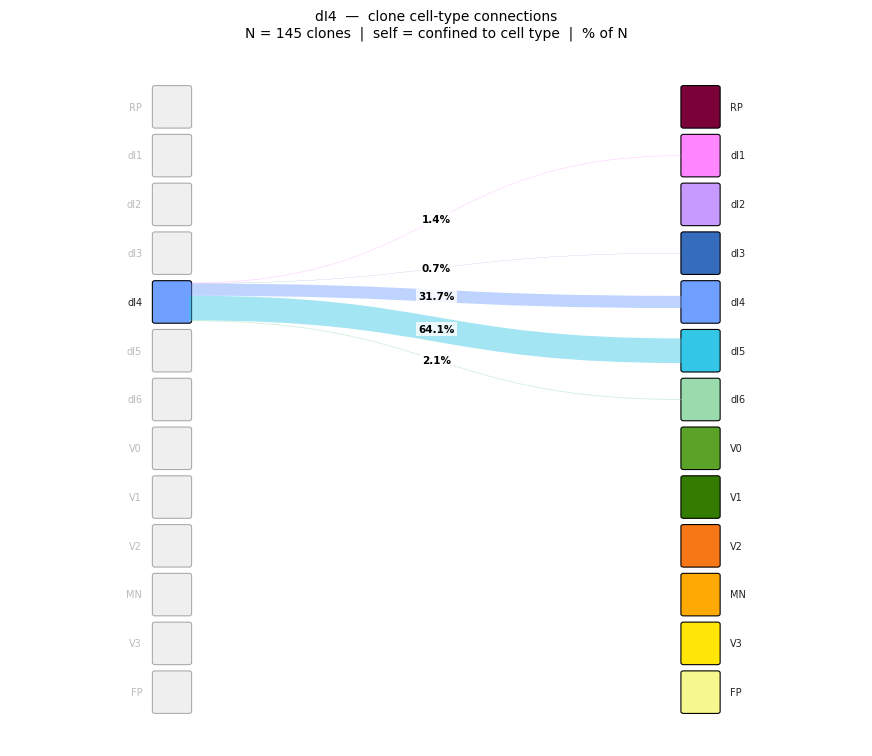

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_dI3_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

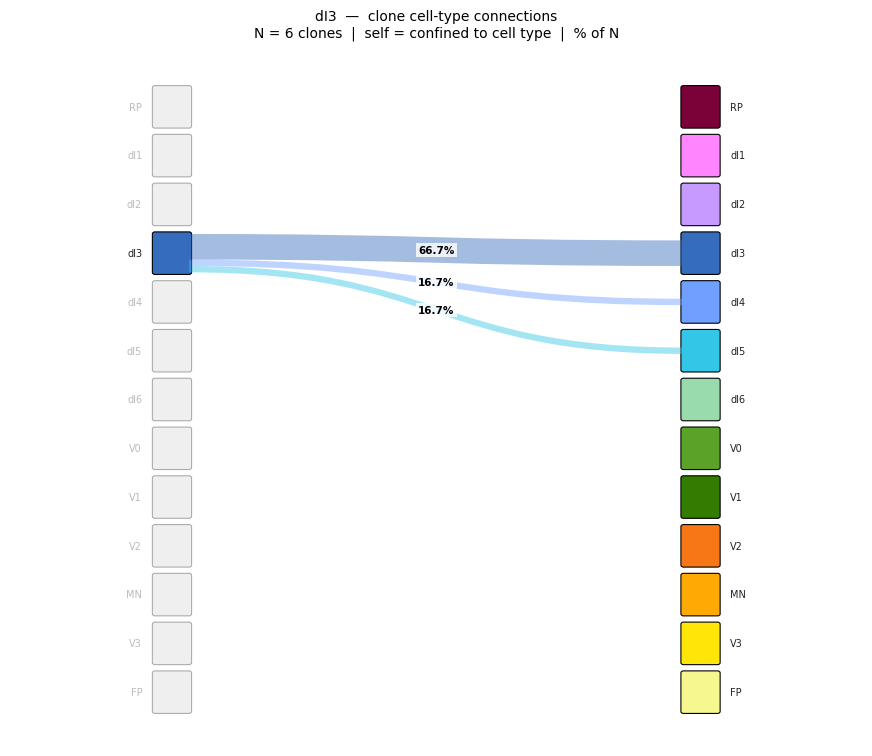

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_dI2_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

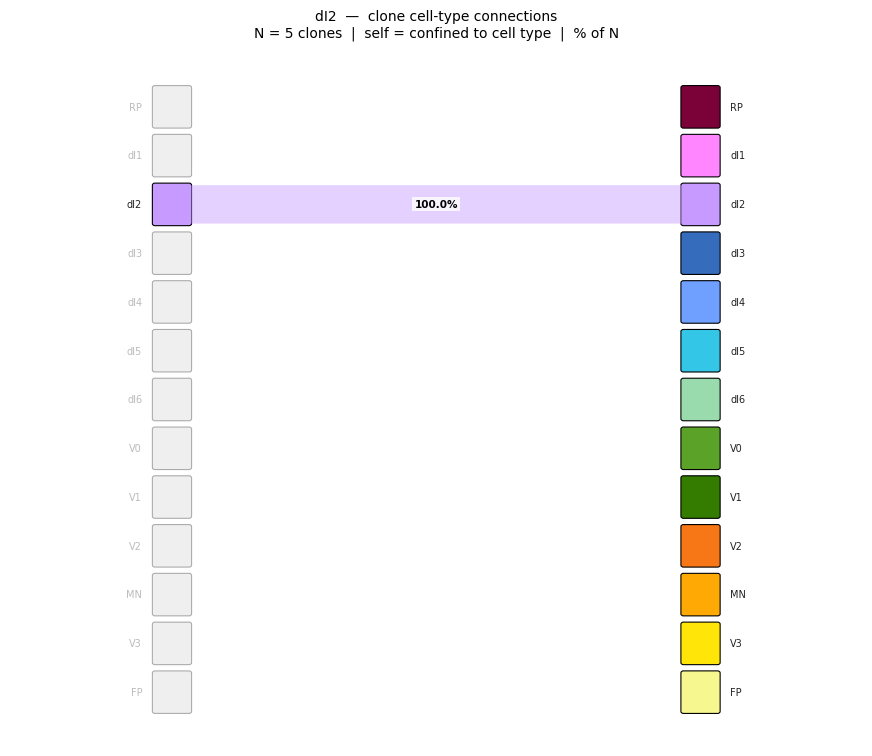

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_dI1_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

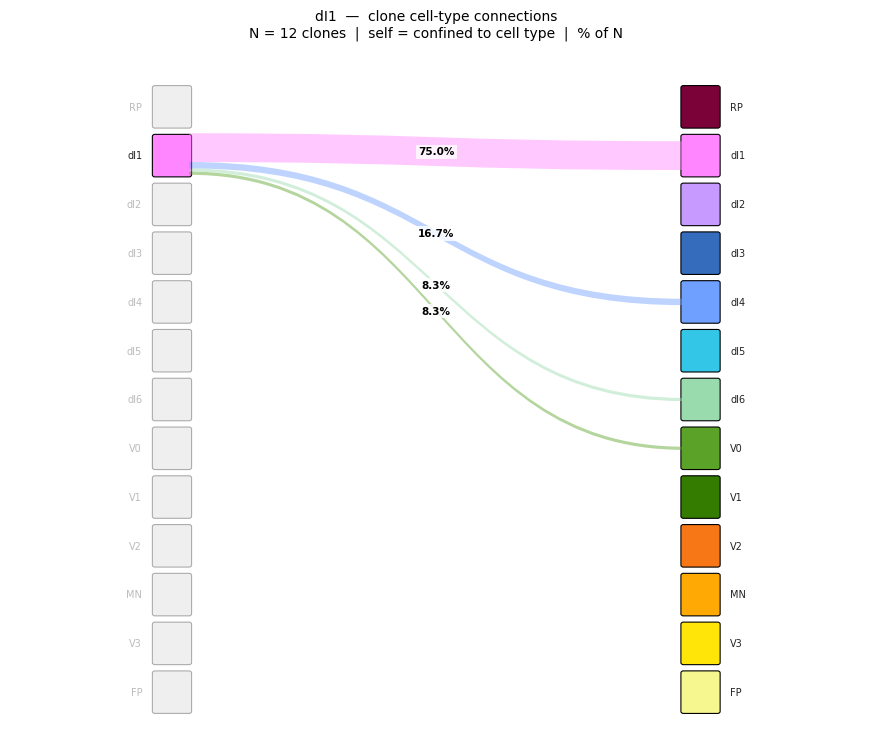

✅ Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/sankey_celltype_RP_NT_injHH16_collHH31.pdf


<Figure size 640x480 with 0 Axes>

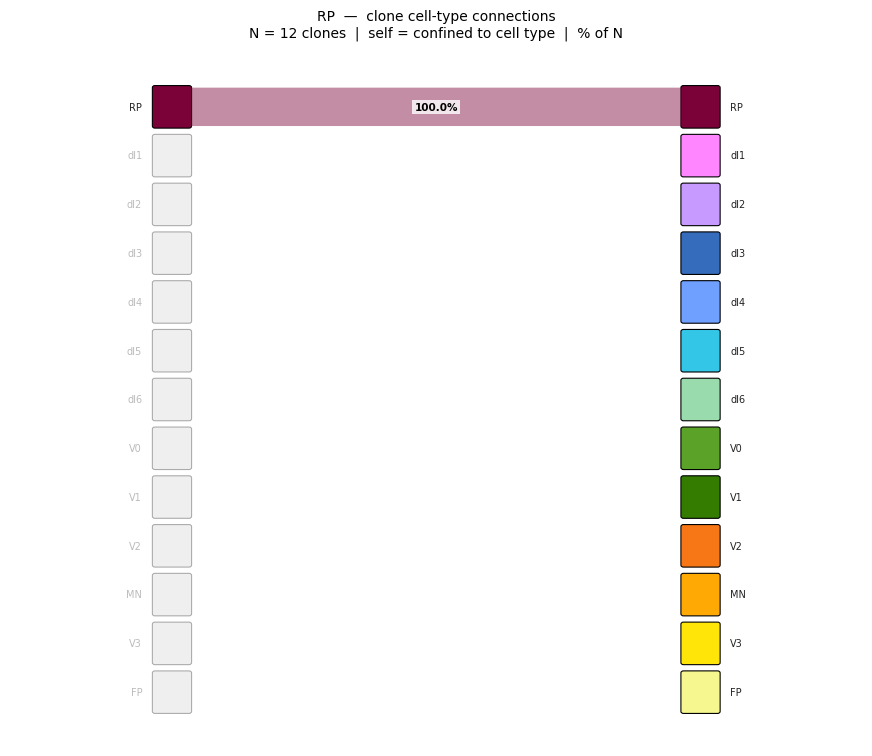

<Figure size 640x480 with 0 Axes>

In [16]:
from matplotlib.path import Path
import matplotlib.patches as mpatches

# ── Cell types to include — edit this list to change which types appear ───────
neuron_types = ["FP", "V3", "MN", "V2", "V1", "V0",
                "dI6", "dI5", "dI4", "dI3", "dI2", "dI1", "RP"]

# ── Mapping from data columns to node names (V2a + V2b → V2) ─────────────────
# Edit here if you want to split V2a/V2b or rename nodes
celltype_to_node = {
    "RP": "RP", "dI1": "dI1", "dI2": "dI2", "dI3": "dI3",
    "dI4": "dI4", "dI5": "dI5",
    "dI6": "dI6", "V0": "V0", "V1": "V1",
    "V2a": "V2", "V2b": "V2",
    "MN": "MN", "V3": "V3", "FP": "FP",
}

# ── Colours ───────────────────────────────────────────────────────────────────
node_palette = {
    "RP":   "#7a0238",
    "dI1":  "#ff86ff",
    "dI2":  "#c79aff",
    "dI3":  "#366cbc",
    "dI4":  "#6fa0ff",
    "dI5":  "#33c6e6",
    "dI6":  "#9adbad",
    "V0":   "#5aa328",
    "V1":   "#337c00",
    "V2":   "#f77615",
    "MN":   "#ffa904",
    "V3":   "#ffe608",
    "FP":   "#f7f78f",
}

# ── Multi-cell filter from full metadata ──────────────────────────────────────
_multi_cell_idx = (chicken_meta[~pd.isna(chicken_meta["clone"])]
                   .groupby("clone").size()
                   .pipe(lambda s: s[s >= 2]).index)

# Restrict to relevant columns and combine V2a+V2b → V2
data_cols = [c for c in clone_celltype_combo_wide.columns if c in celltype_to_node]
cn_ct = clone_celltype_combo_wide.loc[
    clone_celltype_combo_wide.index.isin(_multi_cell_idx), data_cols
].copy()
cn_ct = cn_ct[cn_ct.sum(axis=1) >= 1]

for node in neuron_types:
    src = [c for c, n in celltype_to_node.items() if n == node and c in cn_ct.columns]
    cn_ct[f"n_{node}"] = cn_ct[src].sum(axis=1) if src else 0

cn_ct = cn_ct[[f"n_{node}" for node in neuron_types]]
cn_ct = cn_ct[cn_ct.sum(axis=1) >= 1]

# ── Bezier band ───────────────────────────────────────────────────────────────
def _bezier_band_ct(ax, x0, y0b, y0t, x1, y1b, y1t, color, alpha=0.45):
    cx = (x0 + x1) / 2
    verts = [
        (x0, y0b), (cx, y0b), (cx, y1b), (x1, y1b),
        (x1, y1t), (cx, y1t), (cx, y0t), (x0, y0t),
        (x0, y0b),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(mpatches.PathPatch(
        Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha
    ))

# ── Sankey per focal cell type ────────────────────────────────────────────────
def draw_celltype_sankey(focal_node):
    focal_clones = cn_ct[cn_ct[f"n_{focal_node}"] >= 1]
    N_total = len(focal_clones)
    if N_total == 0:
        print(f"No clones for {focal_node}, skipping.")
        return

    counts = {}
    for t in neuron_types:
        if t == focal_node:
            other_cols = [f"n_{s}" for s in neuron_types if s != focal_node]
            counts[t] = int((focal_clones[other_cols].sum(axis=1) == 0).sum())
        else:
            counts[t] = int((focal_clones[f"n_{t}"] >= 1).sum())

    pcts = {t: 100 * counts[t] / N_total for t in neuron_types}

    # ── layout ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 9))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    nw = 0.4
    xl, xr = 1.9, 8.1
    y0, total_h = 0.5, 9.0
    n = len(neuron_types)
    gap = 0.15
    nh = (total_h - (n - 1) * gap) / n

    ybot = [y0 + i * (nh + gap) for i in range(n)]
    ycen = [yb + nh / 2 for yb in ybot]
    idx  = {s: i for i, s in enumerate(neuron_types)}

    for i, node in enumerate(neuron_types):
        is_focal = node == focal_node
        fc = node_palette[node] if is_focal else "#CCCCCC"
        al = 1.0 if is_focal else 0.3
        ax.add_patch(mpatches.FancyBboxPatch(
            (xl - nw / 2, ybot[i]), nw, nh,
            boxstyle="round,pad=0.03", facecolor=fc, edgecolor="black", linewidth=0.8, alpha=al,
        ))
        ax.text(xl - nw / 2 - 0.15, ycen[i], node,
                ha="right", va="center", fontsize=7,
                color="#222222" if is_focal else "#BBBBBB")

    for i, node in enumerate(neuron_types):
        ax.add_patch(mpatches.FancyBboxPatch(
            (xr - nw / 2, ybot[i]), nw, nh,
            boxstyle="round,pad=0.03", facecolor=node_palette[node], edgecolor="black", linewidth=0.8,
        ))
        ax.text(xr + nw / 2 + 0.15, ycen[i], node,
                ha="left", va="center", fontsize=7, color="#222222")

    fi = idx[focal_node]
    scale = nh / N_total
    left_cursor = ybot[fi]

    for t in neuron_types:
        c = counts[t]
        if c == 0:
            continue
        fh = c * scale
        ti = idx[t]

        ly_b, ly_t = left_cursor, left_cursor + fh
        ry_b = ycen[ti] - fh / 2
        ry_t = ycen[ti] + fh / 2

        _bezier_band_ct(
            ax,
            xl + nw / 2, ly_b, ly_t,
            xr - nw / 2, ry_b, ry_t,
            color=node_palette[t], alpha=0.45,
        )

        mid_y = ((ly_b + ly_t) / 2 + (ry_b + ry_t) / 2) / 2
        ax.text(5.0, mid_y, f"{pcts[t]:.1f}%",
                ha="center", va="center", fontsize=7.5, fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))

        left_cursor += fh

    ax.set_title(
        f"{focal_node}  —  clone cell-type connections\n"
        f"N = {N_total} clones  |  self = confined to cell type  |  % of N",
        fontsize=10, pad=12,
    )

    fname = os.path.join(figures_output, f"sankey_celltype_{focal_node}_{experiment_name}.pdf")
    plt.savefig(fname, format="pdf", bbox_inches="tight")
    print(f"✅ Saved: {fname}")
    plt.show()
    plt.clf()


for fn in neuron_types:
    draw_celltype_sankey(fn)


In [17]:
# ── Subdivisions ──────────────────────────────────────────────────────────────
rows = []
for sub in sub_order:
    focal = cn[cn[f"n_{sub}"] >= 1]
    N_total = len(focal)
    if N_total == 0:
        continue
    other_subs = [s for s in sub_order if s != sub]
    is_confined = focal[[f"n_{s}" for s in other_subs]].sum(axis=1) == 0
    n_confined = int(is_confined.sum())
    n_shared = N_total - n_confined
    rows.append({"subdivision": sub, "members": ", ".join(sub_members[sub]),
                 "total_clones": N_total, "confined": n_confined, "shared": n_shared,
                 "pct_confined": round(100 * n_confined / N_total, 1),
                 "pct_shared":   round(100 * n_shared   / N_total, 1)})

confinement_sub = pd.DataFrame(rows)
print(confinement_sub.to_string(index=False))
confinement_sub.to_csv(
    os.path.join(figures_output, f"confinement_subdivisions_{experiment_name}.csv"), index=False)
print(f"✅ Saved confinement_subdivisions_{experiment_name}.csv")

# ── Neurons ───────────────────────────────────────────────────────────────────
node_members = {}
for src, node in celltype_to_node.items():
    node_members.setdefault(node, []).append(src)

rows = []
for node in neuron_types:
    focal = cn_ct[cn_ct[f"n_{node}"] >= 1]
    N_total = len(focal)
    if N_total == 0:
        continue
    other_nodes = [s for s in neuron_types if s != node]
    is_confined = focal[[f"n_{s}" for s in other_nodes]].sum(axis=1) == 0
    n_confined = int(is_confined.sum())
    n_shared = N_total - n_confined
    rows.append({"cell_type": node, "source_cols": ", ".join(node_members.get(node, [node])),
                 "total_clones": N_total, "confined": n_confined, "shared": n_shared,
                 "pct_confined": round(100 * n_confined / N_total, 1),
                 "pct_shared":   round(100 * n_shared   / N_total, 1)})

confinement_neurons = pd.DataFrame(rows)
print(confinement_neurons.to_string(index=False))
confinement_neurons.to_csv(
    os.path.join(figures_output, f"confinement_neurons_{experiment_name}.csv"), index=False)
print(f"✅ Saved confinement_neurons_{experiment_name}.csv")

subdivision       members  total_clones  confined  shared  pct_confined  pct_shared
      Sub_1            V3             5         4       1          80.0        20.0
      Sub_2  MN, V2a, V2b             8         6       2          75.0        25.0
      Sub_3   V0, V1, dI6            24        17       7          70.8        29.2
      Sub_4 dI3, dI4, dI5           198       191       7          96.5         3.5
      Sub_5      dI1, dI2            17        14       3          82.4        17.6
✅ Saved confinement_subdivisions_NT_injHH16_collHH31.csv
cell_type source_cols  total_clones  confined  shared  pct_confined  pct_shared
       FP          FP             4         4       0         100.0         0.0
       V3          V3             5         4       1          80.0        20.0
       MN          MN             1         1       0         100.0         0.0
       V2    V2a, V2b             7         5       2          71.4        28.6
       V1          V1             5    

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/NT_injHH16_collHH31/confinement_barplots_neurons_between_within.pdf


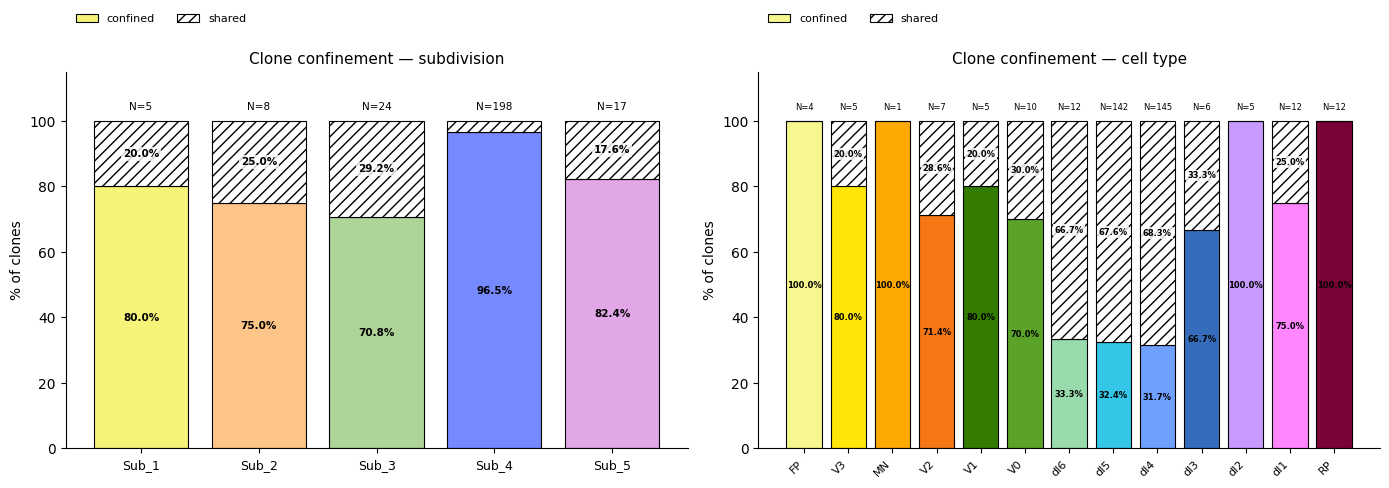

<Figure size 640x480 with 0 Axes>

In [18]:
# ── Confinement bar plots ──────────────────────────────────────────────────────
_ct_df = confinement_neurons

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subdivisions
ax = axes[0]
x = list(range(len(confinement_sub)))
ax.bar(x, confinement_sub["pct_confined"],
       color=[sub_palette[s] for s in confinement_sub["subdivision"]],
       edgecolor="black", linewidth=0.8, label="confined")
ax.bar(x, confinement_sub["pct_shared"],
       bottom=confinement_sub["pct_confined"],
       color="white", edgecolor="black", linewidth=0.8, hatch="///", label="shared")
for i, row in confinement_sub.iterrows():
    if row["pct_confined"] > 5:
        ax.text(i, row["pct_confined"] / 2, f"{row['pct_confined']:.1f}%",
                ha="center", va="center", fontsize=7.5, fontweight="bold")
    if row["pct_shared"] > 5:
        ax.text(i, row["pct_confined"] + row["pct_shared"] / 2, f"{row['pct_shared']:.1f}%",
                ha="center", va="center", fontsize=7.5, fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
    ax.text(i, 103, f"N={row['total_clones']}", ha="center", va="bottom", fontsize=7.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
ax.set_xticks(x)
ax.set_xticklabels(confinement_sub["subdivision"], fontsize=9)
ax.set_ylabel("% of clones", fontsize=10)
ax.set_ylim(0, 115)
ax.set_title("Clone confinement — subdivision", fontsize=11)
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.18), ncol=2, fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# Cell types
ax = axes[1]
x = list(range(len(_ct_df)))
ax.bar(x, _ct_df["pct_confined"],
       color=[node_palette[n] for n in _ct_df["cell_type"]],
       edgecolor="black", linewidth=0.8, label="confined")
ax.bar(x, _ct_df["pct_shared"],
       bottom=_ct_df["pct_confined"],
       color="white", edgecolor="black", linewidth=0.8, hatch="///", label="shared")
for i, row in _ct_df.iterrows():
    if row["pct_confined"] > 5:
        ax.text(i, row["pct_confined"] / 2, f"{row['pct_confined']:.1f}%",
                ha="center", va="center", fontsize=6, fontweight="bold")
    if row["pct_shared"] > 5:
        ax.text(i, row["pct_confined"] + row["pct_shared"] / 2, f"{row['pct_shared']:.1f}%",
                ha="center", va="center", fontsize=6, fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))
    ax.text(i, 103, f"N={row['total_clones']}", ha="center", va="bottom", fontsize=6,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))
ax.set_xticks(x)
ax.set_xticklabels(_ct_df["cell_type"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% of clones", fontsize=10)
ax.set_ylim(0, 115)
ax.set_title("Clone confinement — cell type", fontsize=11)
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.18), ncol=2, fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_plot("confinement_barplots")
plt.show(); plt.clf()
